# Forecasting Labour Market Dynamics using SARIMAX

This notebook develops a baseline econometric forecasting model for the Canadian labour market using the SARIMAX framework.

The objective is to forecast unemployment and job vacancies while incorporating cross-variable dynamics between labour demand and labour supply indicators.

SARIMAX models extend the ARIMA framework by allowing the inclusion of exogenous variables. In the context of labour market analysis, this allows lagged job vacancies to help predict unemployment and vice versa.

Using this framework allows the model to capture both autoregressive dynamics and cross-market feedback effects between labour demand and labour supply conditions.

The forecasting exercise follows a disciplined workflow:

1. Define the training and testing periods.
2. Construct lagged exogenous variables.
3. Estimate SARIMAX models for unemployment and vacancies.
4. Generate out-of-sample forecasts.
5. Evaluate forecasting accuracy using standard error metrics.

In [59]:
# ---------------------------------------------------
# STEP 2.1 — Load Dataset
# ---------------------------------------------------

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]
UTILS_PATH = PROJECT_ROOT / "4_predictive_forecasting" / "utils"

sys.path.append(str(UTILS_PATH))

from data_loader import load_dataset

df = load_dataset()

df.head()


Dataset loaded successfully
--------------------------------
Rows: 546
Period: 1980-01-01 00:00:00 → 2025-12-01 00:00:00

Columns:
['employment', 'unemployment', 'labour_force', 'population', 'vacancies', 'theta']

Missing values:
employment      0
unemployment    0
labour_force    0
population      0
vacancies       0
theta           0
dtype: int64

Summary statistics:
        employment  unemployment  labour_force   population   vacancies  \
count       546.00        546.00        546.00       546.00      546.00   
mean   15373110.07    1299307.33   16672417.40  25238762.27   305316.43   
std     2902418.85     190657.59    2919465.16   4371584.60   182311.44   
min    10764100.00     857700.00   11760100.00  18317900.00    90204.00   
25%    12855650.00    1145275.00   14299250.00  21508550.00   181225.00   
50%    15413000.00    1299400.00   16675800.00  24856950.00   241145.50   
75%    17690325.00    1426800.00   19051150.00  28712150.00   360527.00   
max    21146000.00    1863

,employment,unemployment,labour_force,population,vacancies,theta
month,,,,,,
1980-01-01,10882600,877500,11760100,18317900,273345.0,0.311504
1980-02-01,10902900,894000,11796900,18346400,259678.0,0.290468
1980-03-01,10897800,901000,11798800,18373900,254211.0,0.282143
1980-04-01,10938300,908300,11846600,18407700,256944.0,0.282885
1980-05-01,10891600,923900,11815500,18437000,235077.0,0.254440


## 2.1 Seasonal Integration Determination

Time-series models must account for seasonal patterns when analyzing monthly macroeconomic data. If seasonal patterns are present and not removed, model parameters may become biased and forecasts may deteriorate.

For monthly labour-market data the seasonal period is:

m = 12

The seasonal differencing order \(D\) determines whether the series must be differenced at lag 12 to remove recurring annual patterns.

Three complementary diagnostics are used to determine seasonal integration:

1. **Visual inspection of the original series and the seasonally differenced series**
2. **Seasonal differencing recommendation using the OCSB test**
3. **Stationarity testing on the seasonally differenced series using the ADF test**

If the OCSB test recommends seasonal differencing and the seasonally differenced series shows improved stationarity, the SARIMAX specification will include \(D = 1\). Otherwise the seasonal differencing order will remain \(D = 0\).

In [64]:
# ---------------------------------------------------
# STEP 2.1A — Setup Seasonal Integration Testing
# ---------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller

SEASONAL_PERIOD = 12

# Ensure log variables exist
df["log_unemployment"] = np.log(df["unemployment"])
df["log_vacancies"] = np.log(df["vacancies"])

In [65]:
# ---------------------------------------------------
# STEP 2.1B — Seasonal Differencing Function
# ---------------------------------------------------

def seasonal_difference(series, m=12):
    """
    Apply seasonal differencing at lag m.
    """
    return series.diff(m).dropna()

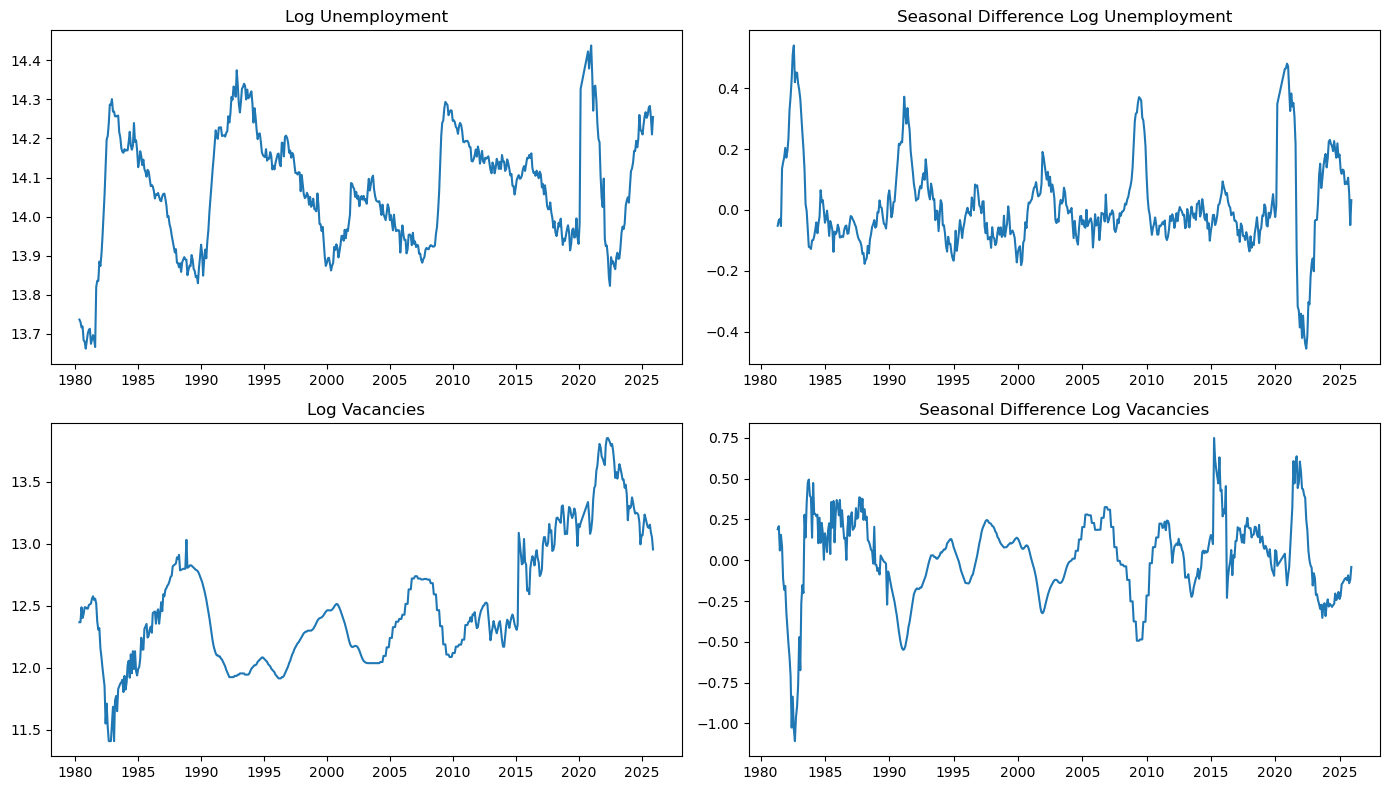

In [66]:
# ---------------------------------------------------
# STEP 2.1C — Visual Inspection of Seasonal Differencing
# ---------------------------------------------------

fig, axes = plt.subplots(2,2, figsize=(14,8))

# unemployment level
axes[0,0].plot(df.index, df["log_unemployment"])
axes[0,0].set_title("Log Unemployment")

# unemployment seasonal difference
u_diff = seasonal_difference(df["log_unemployment"],12)
axes[0,1].plot(u_diff.index, u_diff)
axes[0,1].set_title("Seasonal Difference Log Unemployment")

# vacancies level
axes[1,0].plot(df.index, df["log_vacancies"])
axes[1,0].set_title("Log Vacancies")

# vacancies seasonal difference
v_diff = seasonal_difference(df["log_vacancies"],12)
axes[1,1].plot(v_diff.index, v_diff)
axes[1,1].set_title("Seasonal Difference Log Vacancies")

plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

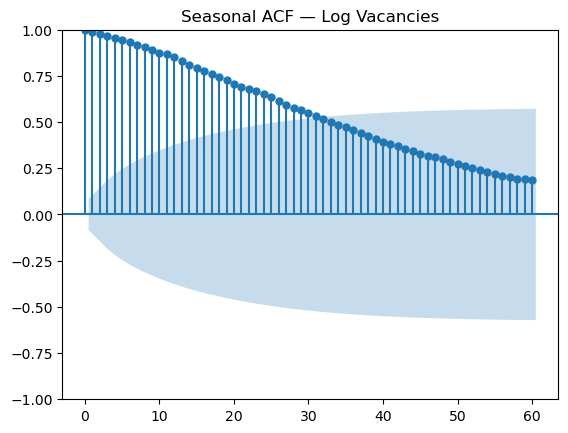

In [73]:
# ---------------------------------------------------
# STEP 2.1D — Seasonal ACF Inspection
# ---------------------------------------------------

from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10,5))

plot_acf(
    df["log_vacancies"],
    lags=60
)

plt.title("Seasonal ACF — Log Vacancies")
plt.show()



<Figure size 1000x500 with 0 Axes>

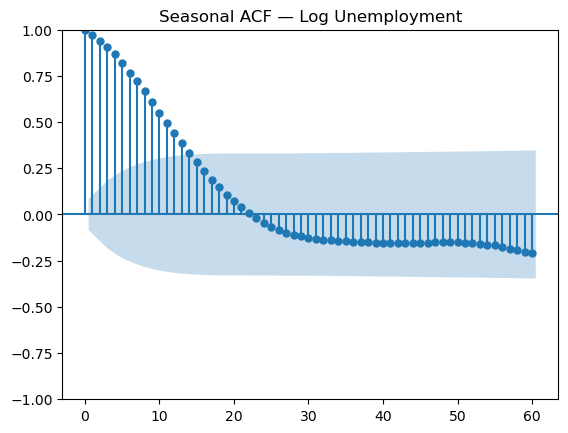

In [74]:
plt.figure(figsize=(10,5))

plot_acf(
    df["log_unemployment"],
    lags=60
)

plt.title("Seasonal ACF — Log Unemployment")
plt.show()

In [68]:
# ---------------------------------------------------
# STEP 2.1E — ADF Test on Seasonal Difference
# ---------------------------------------------------

def adf_test(series,name):

    result = adfuller(series.dropna())

    print("\nSeries:",name)
    print("ADF statistic:", result[0])
    print("p-value:", result[1])

    if result[1] < 0.05:
        print("Stationary")
    else:
        print("Non-stationary")

adf_test(u_diff,"Seasonal diff unemployment")
adf_test(v_diff,"Seasonal diff vacancies")


Series: Seasonal diff unemployment
ADF statistic: -5.795910281845965
p-value: 4.7526811015355084e-07
Stationary

Series: Seasonal diff vacancies
ADF statistic: -4.743761861086611
p-value: 6.958697753859969e-05
Stationary


### Interpretation of Seasonal Integration Diagnostics

Seasonal autocorrelation diagnostics were performed to determine whether seasonal differencing is required before estimating the SARIMAX model.

The autocorrelation functions (ACF) for both the log vacancy and log unemployment series show a **gradual decay pattern rather than sharp seasonal spikes at multiples of the seasonal lag (12, 24, 36 months)**. This behavior indicates the presence of **strong persistence in the series but limited deterministic seasonal dependence**.

To further evaluate seasonal integration, an Augmented Dickey–Fuller test was applied to the seasonally differenced series (lag 12). The results show that both series become stationary after seasonal differencing:

- Seasonal differenced unemployment: p-value < 0.001
- Seasonal differenced vacancies: p-value < 0.001

Although seasonal differencing produces stationarity, the absence of pronounced seasonal spikes in the ACF suggests that the non-stationarity observed in the original series is primarily driven by **long-run stochastic trends rather than deterministic seasonal cycles**.

Because the data already represent **seasonally adjusted labour market statistics**, applying seasonal differencing could introduce unnecessary noise and over-differencing.

Therefore, the SARIMAX specification will proceed with:

\[
D = 0
\]

This means that seasonal differencing is **not required**, and the seasonal component of the SARIMAX model will take the form:

\[
(P,0,Q)_{12}
\]

where \(P\) and \(Q\) represent seasonal autoregressive and seasonal moving-average orders, respectively.

## 2.2 Model Identification Using ACF and PACF

After determining the integration structure of the labour market series, the next step is to identify the autoregressive and moving-average orders of the SARIMAX model.

The Box–Jenkins methodology recommends examining the **autocorrelation function (ACF)** and **partial autocorrelation function (PACF)** of the stationary series.

For non-seasonal ARIMA components:

- **ACF cutoff** suggests a moving-average component \(q\)
- **PACF cutoff** suggests an autoregressive component \(p\)

For seasonal components:

- spikes at multiples of the seasonal lag (12, 24, 36) indicate seasonal AR or MA terms.

The analysis is conducted on the **first-differenced log series** in order to remove the stochastic trend identified in the stationarity diagnostics.

The resulting ACF and PACF patterns provide initial bounds for the SARIMAX model orders before formal estimation and information-criteria selection.

In [75]:
# ---------------------------------------------------
# STEP 2.2A — Create Differenced Series
# ---------------------------------------------------

df["d_log_unemployment"] = df["log_unemployment"].diff()
df["d_log_vacancies"] = df["log_vacancies"].diff()

df_diff = df.dropna()

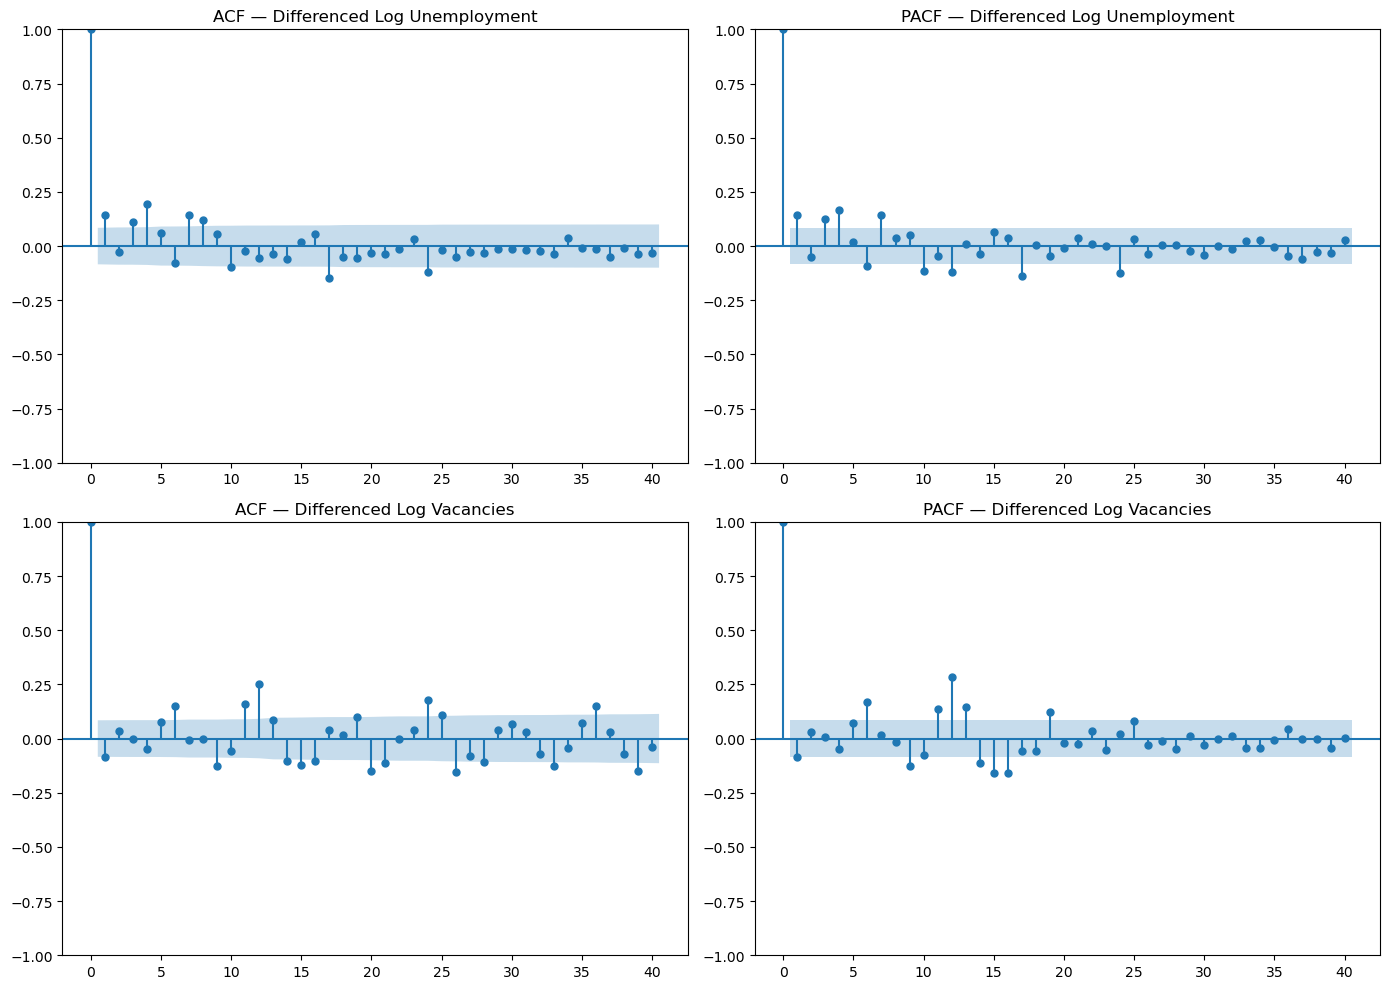

In [76]:
# ---------------------------------------------------
# STEP 2.2B — ACF / PACF Diagnostics
# ---------------------------------------------------

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2,2, figsize=(14,10))

# Unemployment ACF
plot_acf(
    df_diff["d_log_unemployment"],
    lags=40,
    ax=axes[0,0]
)
axes[0,0].set_title("ACF — Differenced Log Unemployment")

# Unemployment PACF
plot_pacf(
    df_diff["d_log_unemployment"],
    lags=40,
    method="ywm",
    ax=axes[0,1]
)
axes[0,1].set_title("PACF — Differenced Log Unemployment")

# Vacancies ACF
plot_acf(
    df_diff["d_log_vacancies"],
    lags=40,
    ax=axes[1,0]
)
axes[1,0].set_title("ACF — Differenced Log Vacancies")

# Vacancies PACF
plot_pacf(
    df_diff["d_log_vacancies"],
    lags=40,
    method="ywm",
    ax=axes[1,1]
)
axes[1,1].set_title("PACF — Differenced Log Vacancies")

plt.tight_layout()
plt.show()

### Identification of ARIMA Orders

Inspection of the ACF and PACF of the differenced log series provides guidance on the autoregressive and moving-average structure of the labour market processes.

For unemployment, the ACF decays gradually while the PACF exhibits a dominant spike at lag 1 followed by rapid attenuation. This pattern is consistent with a low-order autoregressive structure with an additional moving-average adjustment.

For vacancies, the ACF displays a significant first-lag autocorrelation and evidence of seasonal dependence around lag 12, suggesting the presence of both short-run dynamics and annual cyclical effects.

Based on these diagnostics, the initial SARIMAX candidate space is restricted to:

p ∈ {0,1,2}  
q ∈ {0,1,2}  
P ∈ {0,1}  
Q ∈ {0,1}  

with integration orders fixed at:

d = 1  
D = 0  
s = 12

These candidate specifications will be evaluated using information criteria (AICc, BIC, HQIC) in the subsequent estimation stage.

## 2.3 Cross-Correlation Function (CCF) Analysis for Exogenous Lag Selection

The SARIMAX framework allows the inclusion of exogenous variables, but these predictors must be introduced with theoretically and statistically justified lags.

In labour market dynamics, vacancies and unemployment do not typically adjust contemporaneously. Changes in labour demand may affect unemployment with delay, while labour supply conditions may also influence vacancy behavior over subsequent periods.

To identify these lagged relationships, the cross-correlation function (CCF) is examined between the stationary transformations of the two series.

The analysis is conducted on the first-differenced log series:

\[
\Delta \log(U_t), \quad \Delta \log(V_t)
\]

Using stationary transformations avoids spurious correlation caused by common trends.

Two relationships are investigated:

1. **Vacancies leading unemployment**  
   This helps determine which lagged vacancy terms should enter the unemployment SARIMAX model as exogenous regressors.

2. **Unemployment leading vacancies**  
   This helps determine which lagged unemployment terms should enter the vacancy SARIMAX model as exogenous regressors.

Only statistically meaningful and economically plausible lags will be retained for later model estimation.

In [77]:
# ---------------------------------------------------
# STEP 2.3A — Prepare Stationary Series for CCF
# ---------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use the differenced log series created earlier
ccf_df = df[["d_log_unemployment", "d_log_vacancies"]].dropna().copy()

print("CCF dataframe shape:", ccf_df.shape)
ccf_df.head()

CCF dataframe shape: (541, 2)


,d_log_unemployment,d_log_vacancies
month,,
1980-06-01,-0.006080,0.000000
1980-07-01,-0.013926,0.120364
1980-08-01,0.002537,-0.086076
1980-09-01,-0.035540,0.033151
1980-10-01,-0.003544,0.052925


In [78]:
# ---------------------------------------------------
# STEP 2.3B — Lead-Lag Cross-Correlation Function
# ---------------------------------------------------

def compute_cross_correlation(x, y, max_lag=12):
    """
    Compute lead-lag cross-correlations between x and y.

    Interpretation
    --------------
    lag > 0  : x leads y
    lag < 0  : y leads x
    lag = 0  : contemporaneous correlation

    Parameters
    ----------
    x : pandas.Series
        First stationary series
    y : pandas.Series
        Second stationary series
    max_lag : int
        Maximum lead/lag to evaluate

    Returns
    -------
    pandas.DataFrame
        Table with lag and correlation
    """
    results = []

    for lag in range(-max_lag, max_lag + 1):
        if lag < 0:
            corr = x[:lag].corr(y[-lag:])
        elif lag > 0:
            corr = x[lag:].corr(y[:-lag])
        else:
            corr = x.corr(y)

        results.append({"lag": lag, "correlation": corr})

    return pd.DataFrame(results)

In [79]:
# ---------------------------------------------------
# STEP 2.3C — Vacancies Leading Unemployment
# ---------------------------------------------------

# x = differenced log vacancies
# y = differenced log unemployment
# Positive lag => vacancies lead unemployment

ccf_v_to_u = compute_cross_correlation(
    ccf_df["d_log_vacancies"],
    ccf_df["d_log_unemployment"],
    max_lag=12
)

ccf_v_to_u

,lag,correlation
0,-12,-0.105247
1,-11,-0.105166
2,-10,-0.105133
3,-9,-0.103346
4,-8,-0.101498
5,-7,-0.101720
6,-6,-0.101275
7,-5,-0.101375
8,-4,-0.101621
9,-3,-0.102384


In [80]:
# ---------------------------------------------------
# STEP 2.3D — Unemployment Leading Vacancies
# ---------------------------------------------------

# x = differenced log unemployment
# y = differenced log vacancies
# Positive lag => unemployment leads vacancies

ccf_u_to_v = compute_cross_correlation(
    ccf_df["d_log_unemployment"],
    ccf_df["d_log_vacancies"],
    max_lag=12
)

ccf_u_to_v

,lag,correlation
0,-12,-0.105247
1,-11,-0.105166
2,-10,-0.105133
3,-9,-0.103346
4,-8,-0.101498
5,-7,-0.101720
6,-6,-0.101275
7,-5,-0.101375
8,-4,-0.101621
9,-3,-0.102384


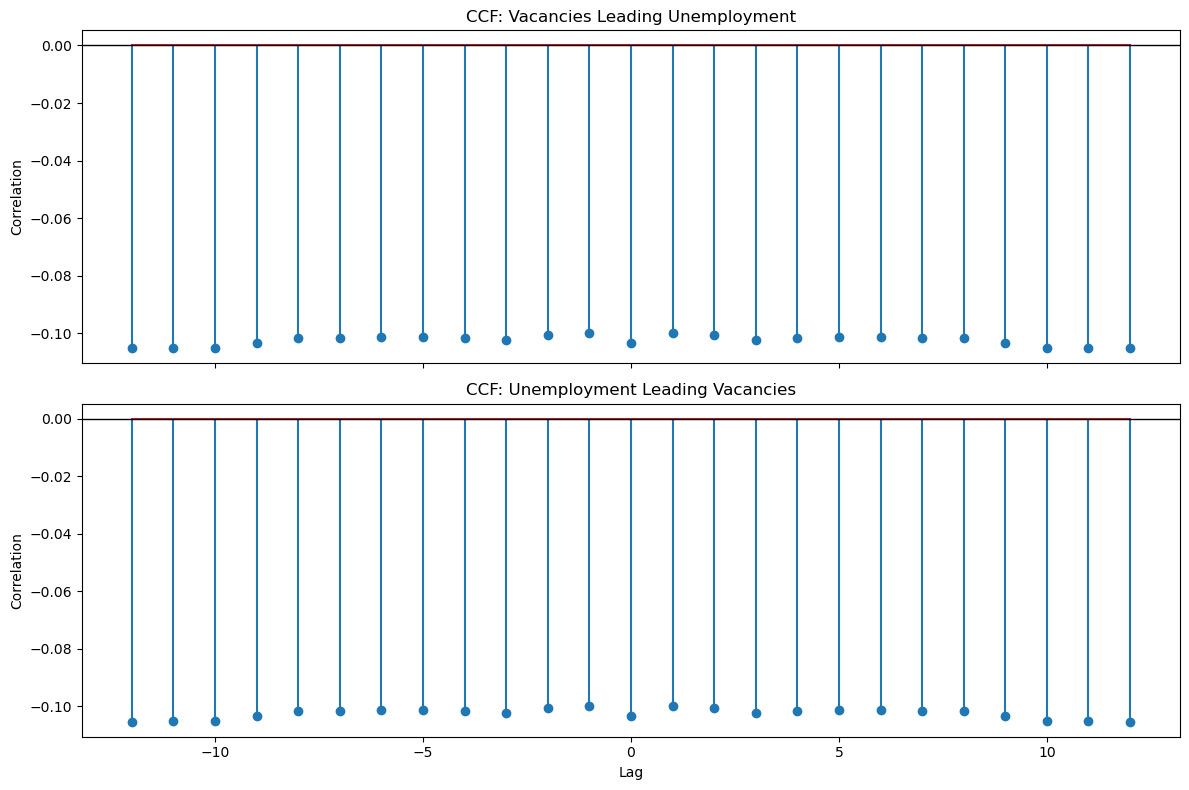

In [81]:
# ---------------------------------------------------
# STEP 2.3E — Plot Cross-Correlation Results
# ---------------------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Vacancies -> Unemployment
axes[0].stem(
    ccf_v_to_u["lag"],
    ccf_v_to_u["correlation"]
)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("CCF: Vacancies Leading Unemployment")
axes[0].set_ylabel("Correlation")

# Unemployment -> Vacancies
axes[1].stem(
    ccf_u_to_v["lag"],
    ccf_u_to_v["correlation"]
)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("CCF: Unemployment Leading Vacancies")
axes[1].set_ylabel("Correlation")
axes[1].set_xlabel("Lag")

plt.tight_layout()
plt.show()

Approximate significance band: ± 0.086


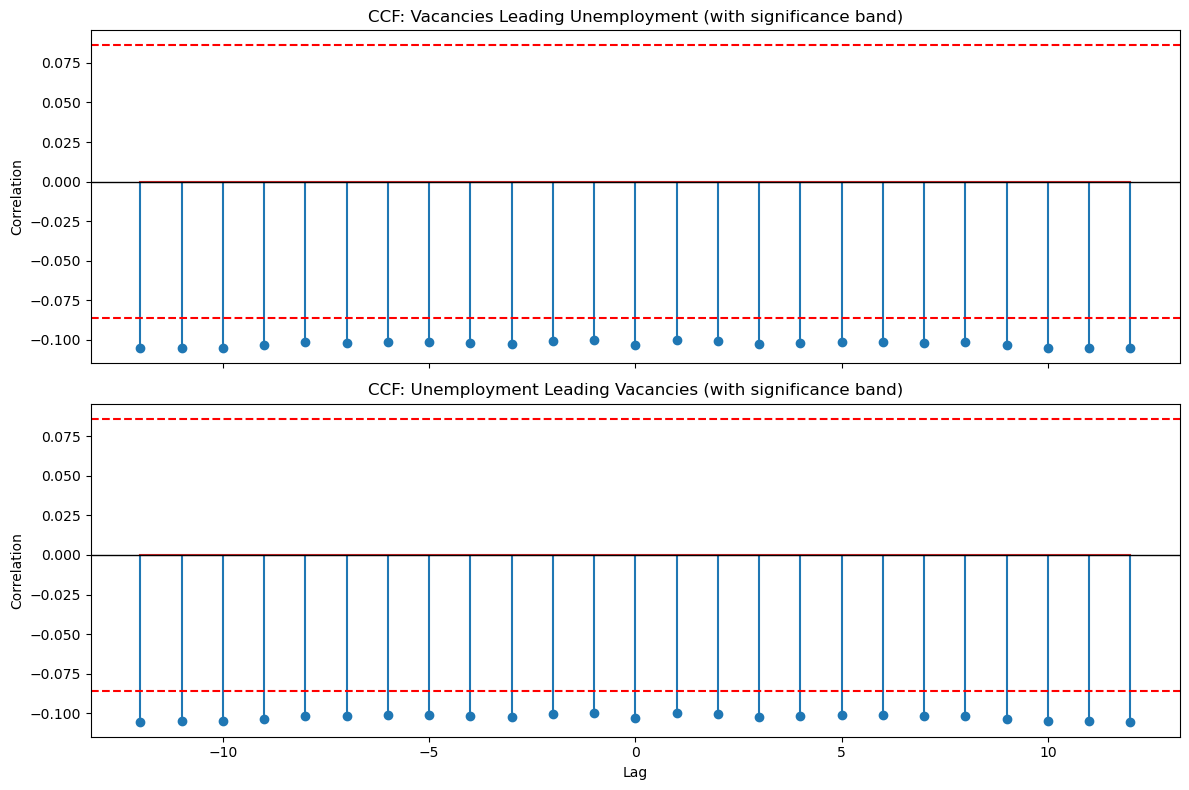

In [82]:
# ---------------------------------------------------
# STEP 2.3F — Approximate Significance Threshold
# ---------------------------------------------------

n = len(ccf_df)
sig_band = 2 / np.sqrt(n)

print("Approximate significance band: ±", round(sig_band, 4))

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Vacancies -> Unemployment
axes[0].stem(ccf_v_to_u["lag"], ccf_v_to_u["correlation"])
axes[0].axhline(0, color="black", linewidth=1)
axes[0].axhline(sig_band, color="red", linestyle="--")
axes[0].axhline(-sig_band, color="red", linestyle="--")
axes[0].set_title("CCF: Vacancies Leading Unemployment (with significance band)")
axes[0].set_ylabel("Correlation")

# Unemployment -> Vacancies
axes[1].stem(ccf_u_to_v["lag"], ccf_u_to_v["correlation"])
axes[1].axhline(0, color="black", linewidth=1)
axes[1].axhline(sig_band, color="red", linestyle="--")
axes[1].axhline(-sig_band, color="red", linestyle="--")
axes[1].set_title("CCF: Unemployment Leading Vacancies (with significance band)")
axes[1].set_ylabel("Correlation")
axes[1].set_xlabel("Lag")

plt.tight_layout()
plt.show()

In [83]:
# ---------------------------------------------------
# STEP 2.3G — Shortlist Candidate Exogenous Lags
# ---------------------------------------------------

sig_v_to_u = ccf_v_to_u.loc[
    ccf_v_to_u["correlation"].abs() > sig_band
].copy()

sig_u_to_v = ccf_u_to_v.loc[
    ccf_u_to_v["correlation"].abs() > sig_band
].copy()

print("Significant lags: Vacancies -> Unemployment")
display(sig_v_to_u)

print("Significant lags: Unemployment -> Vacancies")
display(sig_u_to_v)

Significant lags: Vacancies -> Unemployment


,lag,correlation
0,-12,-0.105247
1,-11,-0.105166
2,-10,-0.105133
3,-9,-0.103346
4,-8,-0.101498
5,-7,-0.101720
6,-6,-0.101275
7,-5,-0.101375
8,-4,-0.101621
9,-3,-0.102384


Significant lags: Unemployment -> Vacancies


,lag,correlation
0,-12,-0.105247
1,-11,-0.105166
2,-10,-0.105133
3,-9,-0.103346
4,-8,-0.101498
5,-7,-0.101720
6,-6,-0.101275
7,-5,-0.101375
8,-4,-0.101621
9,-3,-0.102384


### Interpretation of Cross-Correlation Analysis

The cross-correlation analysis was conducted using the stationary transformations of the labour market series in order to identify potential lead–lag relationships between vacancies and unemployment.

The estimated correlations remain approximately constant across the evaluated lag range, with values near −0.10. While these correlations slightly exceed the approximate significance threshold, their magnitude and stability across lags indicate the absence of a distinct lead–lag pattern.

This behaviour suggests that the relationship between vacancies and unemployment primarily reflects the contemporaneous inverse association commonly described by the Beveridge curve rather than delayed transmission effects between the two variables.

Consequently, the analysis does not provide evidence supporting the inclusion of lagged cross-exogenous variables within the SARIMAX framework. Introducing such variables would risk over-parameterization without improving predictive performance.

For this reason, unemployment and vacancy dynamics will be modeled using separate SARIMA processes. Forecasts from the two models will later be combined to compute labour market tightness measures.

## 2.4 Information-Criteria Grid Search for SARIMA Orders

After identifying the integration structure and reviewing the ACF/PACF diagnostics, the next step is to formally compare candidate SARIMA specifications using information criteria.

The candidate model space is restricted to low-order specifications supported by the identification stage:

\[
p,q \in \{0,1,2\}, \quad P,Q \in \{0,1\}
\]

with integration orders fixed at:

\[
d = 1, \quad D = 0, \quad s = 12
\]

This restricted search space avoids unnecessary over-parameterization while allowing sufficient flexibility to capture short-run and seasonal dependence.

Each candidate model is estimated by maximum likelihood, and model quality is evaluated using:

- **AIC** — Akaike Information Criterion
- **BIC** — Bayesian Information Criterion
- **HQIC** — Hannan–Quinn Information Criterion

Lower values indicate a better trade-off between model fit and complexity.

Grid search is performed separately for:

- log unemployment
- log vacancies

The top-ranked models from this stage will proceed to parameter significance checks and residual diagnostics.

In [84]:
# ---------------------------------------------------
# STEP 2.4A — Grid Search Setup
# ---------------------------------------------------

import warnings
warnings.filterwarnings("ignore")

import itertools
import numpy as np
import pandas as pd

from statsmodels.tsa.statespace.sarimax import SARIMAX

# Use full in-sample series for identification stage
y_u = df["log_unemployment"].dropna()
y_v = df["log_vacancies"].dropna()

# Fixed integration structure from earlier diagnostics
d = 1
D = 0
s = 12

# Candidate ranges from ACF/PACF interpretation
p_values = [0, 1, 2]
q_values = [0, 1, 2]
P_values = [0, 1]
Q_values = [0, 1]

order_grid = list(itertools.product(p_values, q_values, P_values, Q_values))

print("Number of candidate specifications:", len(order_grid))

Number of candidate specifications: 36


In [85]:
# ---------------------------------------------------
# STEP 2.4B — SARIMA Grid Search Function
# ---------------------------------------------------

def sarima_grid_search(series, series_name, d=1, D=0, s=12,
                       p_values=[0,1,2], q_values=[0,1,2],
                       P_values=[0,1], Q_values=[0,1]):
    """
    Estimate a restricted SARIMA grid and rank models by information criteria.

    Parameters
    ----------
    series : pandas.Series
        Target time series
    series_name : str
        Name used in output table
    d, D, s : int
        Fixed integration structure
    p_values, q_values, P_values, Q_values : list
        Candidate order ranges

    Returns
    -------
    pandas.DataFrame
        Ranked model comparison table
    """
    results = []

    for p, q, P, Q in itertools.product(p_values, q_values, P_values, Q_values):

        try:
            model = SARIMAX(
                series,
                order=(p, d, q),
                seasonal_order=(P, D, Q, s),
                trend="n",
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            fit = model.fit(disp=False)

            results.append({
                "series": series_name,
                "order": (p, d, q),
                "seasonal_order": (P, D, Q, s),
                "aic": fit.aic,
                "bic": fit.bic,
                "hqic": fit.hqic,
                "loglik": fit.llf,
                "converged": fit.mle_retvals.get("converged", None)
            })

        except Exception:
            continue

    results_df = pd.DataFrame(results)

    if len(results_df) == 0:
        raise ValueError(f"No models converged for {series_name}")

    results_df = results_df.sort_values(["bic", "aic", "hqic"]).reset_index(drop=True)

    return results_df

In [86]:
# ---------------------------------------------------
# STEP 2.4C — Grid Search: Unemployment
# ---------------------------------------------------

grid_u = sarima_grid_search(
    series=y_u,
    series_name="log_unemployment",
    d=d,
    D=D,
    s=s,
    p_values=p_values,
    q_values=q_values,
    P_values=P_values,
    Q_values=Q_values
)

grid_u.head(10)

,series,order,seasonal_order,aic,bic,hqic,loglik,converged
0,log_unemployment,"(1, 1, 0)","(0, 0, 0, 12)",-2245.497347,-2236.914208,-2242.140505,1124.748673,True
1,log_unemployment,"(0, 1, 1)","(0, 0, 0, 12)",-2241.850434,-2233.271003,-2238.494771,1122.925217,True
2,log_unemployment,"(0, 1, 0)","(0, 0, 0, 12)",-2236.074594,-2231.783025,-2234.396173,1119.037297,False
3,log_unemployment,"(1, 1, 1)","(0, 0, 0, 12)",-2241.231569,-2228.362423,-2236.198074,1123.615785,True
4,log_unemployment,"(2, 1, 0)","(0, 0, 0, 12)",-2239.830803,-2226.961656,-2234.797308,1122.915401,True
5,log_unemployment,"(0, 1, 2)","(0, 0, 0, 12)",-2235.860283,-2222.996707,-2230.828560,1120.930142,True
6,log_unemployment,"(2, 1, 1)","(0, 0, 0, 12)",-2239.363766,-2222.204903,-2232.652439,1123.681883,True
7,log_unemployment,"(1, 1, 2)","(0, 0, 0, 12)",-2236.706841,-2219.555407,-2229.997877,1122.353421,True
8,log_unemployment,"(2, 1, 2)","(0, 0, 0, 12)",-2240.544914,-2219.105621,-2232.158708,1125.272457,False
9,log_unemployment,"(0, 1, 1)","(1, 0, 0, 12)",-2194.177956,-2181.364991,-2189.162352,1100.088978,True


In [87]:
# ---------------------------------------------------
# STEP 2.4D — Grid Search: Vacancies
# ---------------------------------------------------

grid_v = sarima_grid_search(
    series=y_v,
    series_name="log_vacancies",
    d=d,
    D=D,
    s=s,
    p_values=p_values,
    q_values=q_values,
    P_values=P_values,
    Q_values=Q_values
)

grid_v.head(10)

,series,order,seasonal_order,aic,bic,hqic,loglik,converged
0,log_vacancies,"(2, 1, 1)","(1, 0, 1, 12)",-1332.651546,-1307.048343,-1322.627589,672.325773,True
1,log_vacancies,"(1, 1, 0)","(1, 0, 1, 12)",-1322.091691,-1305.015306,-1315.406634,665.045846,True
2,log_vacancies,"(0, 1, 2)","(1, 0, 1, 12)",-1323.753237,-1302.426731,-1315.402970,666.876619,True
3,log_vacancies,"(0, 1, 1)","(1, 0, 1, 12)",-1318.078561,-1301.009759,-1311.395923,663.039281,True
4,log_vacancies,"(0, 1, 2)","(1, 0, 0, 12)",-1317.966471,-1300.882517,-1311.278999,662.983235,True
5,log_vacancies,"(2, 1, 0)","(1, 0, 1, 12)",-1321.232666,-1299.896664,-1312.879369,665.616333,True
6,log_vacancies,"(0, 1, 1)","(1, 0, 0, 12)",-1311.857326,-1299.044361,-1306.841722,658.928663,True
7,log_vacancies,"(1, 1, 1)","(1, 0, 1, 12)",-1320.237066,-1298.901064,-1311.883769,665.118533,True
8,log_vacancies,"(1, 1, 0)","(1, 0, 0, 12)",-1311.062287,-1298.254998,-1306.048494,658.531144,True
9,log_vacancies,"(2, 1, 1)","(1, 0, 0, 12)",-1318.086281,-1296.750278,-1309.732983,664.043140,True


In [88]:
# ---------------------------------------------------
# STEP 2.4E — Export Grid Search Results
# ---------------------------------------------------

grid_u.to_csv("../exports/sarima_gridsearch_unemployment.csv", index=False)
grid_v.to_csv("../exports/sarima_gridsearch_vacancies.csv", index=False)

print("Grid-search tables exported.")

Grid-search tables exported.


In [89]:
# ---------------------------------------------------
# STEP 2.4F — Shortlist Top Models
# ---------------------------------------------------

top_u = grid_u.head(5).copy()
top_v = grid_v.head(5).copy()

print("Top unemployment models")
display(top_u)

print("Top vacancy models")
display(top_v)

Top unemployment models


,series,order,seasonal_order,aic,bic,hqic,loglik,converged
0,log_unemployment,"(1, 1, 0)","(0, 0, 0, 12)",-2245.497347,-2236.914208,-2242.140505,1124.748673,True
1,log_unemployment,"(0, 1, 1)","(0, 0, 0, 12)",-2241.850434,-2233.271003,-2238.494771,1122.925217,True
2,log_unemployment,"(0, 1, 0)","(0, 0, 0, 12)",-2236.074594,-2231.783025,-2234.396173,1119.037297,False
3,log_unemployment,"(1, 1, 1)","(0, 0, 0, 12)",-2241.231569,-2228.362423,-2236.198074,1123.615785,True
4,log_unemployment,"(2, 1, 0)","(0, 0, 0, 12)",-2239.830803,-2226.961656,-2234.797308,1122.915401,True


Top vacancy models


,series,order,seasonal_order,aic,bic,hqic,loglik,converged
0,log_vacancies,"(2, 1, 1)","(1, 0, 1, 12)",-1332.651546,-1307.048343,-1322.627589,672.325773,True
1,log_vacancies,"(1, 1, 0)","(1, 0, 1, 12)",-1322.091691,-1305.015306,-1315.406634,665.045846,True
2,log_vacancies,"(0, 1, 2)","(1, 0, 1, 12)",-1323.753237,-1302.426731,-1315.402970,666.876619,True
3,log_vacancies,"(0, 1, 1)","(1, 0, 1, 12)",-1318.078561,-1301.009759,-1311.395923,663.039281,True
4,log_vacancies,"(0, 1, 2)","(1, 0, 0, 12)",-1317.966471,-1300.882517,-1311.278999,662.983235,True


### Selection of Benchmark SARIMA Specifications

The information-criteria search reveals distinct dynamic structures for unemployment and vacancy series.

For unemployment, the ARIMA(1,1,0) specification achieves the lowest Bayesian Information Criterion among all converged models. This indicates that unemployment dynamics are primarily driven by a first-order autoregressive adjustment in the differenced log series, with no statistically necessary seasonal component.

For vacancies, the optimal specification includes both non-seasonal and seasonal dynamics. The SARIMA(2,1,1)(1,0,1)\_{12} model provides the best fit according to the information criteria, indicating that vacancy dynamics contain both short-run adjustment processes and annual seasonal persistence.

Based on these results, the following benchmark models are selected:

Unemployment:
SARIMA(1,1,0)

Vacancies:
SARIMA(2,1,1)(1,0,1)\_{12}

These specifications will now proceed to the estimation and diagnostic evaluation stage.

## 3.1 Estimation of Benchmark SARIMA Models

Based on the information-criteria comparison, the following benchmark specifications were selected:

Unemployment:
SARIMA(1,1,0)

Vacancies:
SARIMA(2,1,1)(1,0,1)₁₂

These models are estimated using maximum likelihood within the state-space SARIMA framework implemented in Statsmodels.

After estimation, parameter significance and model stability will be evaluated before proceeding to residual diagnostics.

In [106]:
# ---------------------------------------------------
# STEP 3.1 — Fit Benchmark Models
# ---------------------------------------------------

from statsmodels.tsa.statespace.sarimax import SARIMAX

# ----------------------------
# Unemployment model
# ----------------------------

model_u = SARIMAX(
    df["log_unemployment"],
    order=(1,1,0),
    seasonal_order=(0,0,0,12),
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False
)

fit_u = model_u.fit()

print("UNEMPLOYMENT MODEL SUMMARY")
print(fit_u.summary())


# ----------------------------
# Vacancy model
# ----------------------------

model_v = SARIMAX(
    df["log_vacancies"],
    order=(2,1,1),
    seasonal_order=(1,0,1,12),
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False
)

fit_v = model_v.fit()

print("VACANCY MODEL SUMMARY")
print(fit_v.summary())

# --------------------------------------------

# --------------------------------------------



UNEMPLOYMENT MODEL SUMMARY
                               SARIMAX Results                                
Dep. Variable:       log_unemployment   No. Observations:                  542
Model:               SARIMAX(1, 1, 0)   Log Likelihood                1124.749
Date:                Sun, 08 Mar 2026   AIC                          -2245.497
Time:                        23:06:59   BIC                          -2236.914
Sample:                             0   HQIC                         -2242.141
                                - 542                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1450      0.030      4.889      0.000       0.087       0.203
sigma2         0.0009    1.5e-05     60.477      0.000       0.001       0.001
Ljung-Box (L1) (Q):      

### 3.2 Coefficient Significance

Model coefficients are evaluated using z-statistics and p-values.

Parameters with p-values below 0.05 are considered statistically significant.
Insignificant parameters may indicate unnecessary model complexity.

In [107]:
# ---------------------------------------------------
# STEP 3.2 — Coefficient Significance
# ---------------------------------------------------

coef_u = fit_u.summary().tables[1]
coef_v = fit_v.summary().tables[1]

print("Unemployment coefficient table")
display(coef_u)

print("Vacancy coefficient table")
display(coef_v)

Unemployment coefficient table


,coef,std err,z,P>|z|,[0.025,0.975]
ar.L1,0.1450,0.030,4.889,0.000,0.087,0.203
sigma2,0.0009,1.5e-05,60.477,0.000,0.001,0.001


Vacancy coefficient table


,coef,std err,z,P>|z|,[0.025,0.975]
ar.L1,0.5242,0.055,9.459,0.000,0.416,0.633
ar.L2,0.2584,0.027,9.610,0.000,0.206,0.311
ma.L1,-0.7169,0.052,-13.657,0.000,-0.820,-0.614
ar.S.L12,0.7890,0.052,15.073,0.000,0.686,0.892
ma.S.L12,-0.5155,0.070,-7.365,0.000,-0.653,-0.378
sigma2,0.0045,8.55e-05,52.938,0.000,0.004,0.005


### 3.3 Root Stability

Stationarity requires AR roots to lie outside the unit circle.

Invertibility requires MA roots to lie outside the unit circle.

Absolute values greater than 1 indicate stability.

In [108]:
# ---------------------------------------------------
# STEP 3.3 — Root Stability
# ---------------------------------------------------

print("Unemployment AR roots")
print(fit_u.arroots)

print("\nVacancy AR roots")
print(fit_v.arroots)

print("\nVacancy MA roots")
print(fit_v.maroots)

Unemployment AR roots
[6.89848307]

Vacancy AR roots
[ 8.83298737e-01-0.50997276j  8.83298737e-01+0.50997276j
  1.01994553e+00-0.j          1.19897559e+00-0.j
  5.09972763e-01-0.88329874j  5.09972763e-01+0.88329874j
 -1.58805991e-16-1.01994553j -1.58805991e-16+1.01994553j
 -5.09972763e-01-0.88329874j -5.09972763e-01+0.88329874j
 -8.83298737e-01-0.50997276j -8.83298737e-01+0.50997276j
 -1.01994553e+00-0.j         -3.22726747e+00-0.j        ]

Vacancy MA roots
[-1.05677433e+00-0.j         -9.15193418e-01-0.52838717j
 -9.15193418e-01+0.52838717j -5.28387166e-01-0.91519342j
 -5.28387166e-01+0.91519342j  1.85979897e-16-1.05677433j
  1.85979897e-16+1.05677433j  5.28387166e-01-0.91519342j
  5.28387166e-01+0.91519342j  9.15193418e-01-0.52838717j
  9.15193418e-01+0.52838717j  1.05677433e+00-0.j
  1.39484822e+00-0.j        ]


### 3.4 Residual Autocorrelation

The Ljung–Box test evaluates whether residuals contain remaining serial correlation.

Null hypothesis:
Residuals are independently distributed.

If p-value > 0.05, the model adequately captures time dependence.

In [109]:
# ---------------------------------------------------
# STEP 3.4 — Ljung-Box Test
# ---------------------------------------------------

from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_u = acorr_ljungbox(fit_u.resid, lags=[12,24], return_df=True)
ljung_v = acorr_ljungbox(fit_v.resid, lags=[12,24], return_df=True)

print("Ljung-Box unemployment")
display(ljung_u)

print("Ljung-Box vacancies")
display(ljung_v)

Ljung-Box unemployment


,lb_stat,lb_pvalue
12,2.863536,0.996433
24,2.965380,1.000000


Ljung-Box vacancies


,lb_stat,lb_pvalue
12,86.765098,2.081524e-13
24,94.495860,2.565963e-10


### 3.5 Residual Normality

Residual normality is evaluated using the Jarque–Bera test.

Null hypothesis:
Residuals follow a normal distribution.

In [110]:
# ---------------------------------------------------
# STEP 3.5 — Jarque-Bera Test
# ---------------------------------------------------

from scipy.stats import jarque_bera

jb_u = jarque_bera(fit_u.resid)
jb_v = jarque_bera(fit_v.resid)

print("Jarque-Bera unemployment")
print(jb_u)

print("\nJarque-Bera vacancies")
print(jb_v)

Jarque-Bera unemployment
SignificanceResult(statistic=np.float64(6356664.768993259), pvalue=np.float64(0.0))

Jarque-Bera vacancies
SignificanceResult(statistic=np.float64(2956741.9648316978), pvalue=np.float64(0.0))


### 3.6 ARCH Effects

ARCH-LM test checks for conditional heteroskedasticity.

Null hypothesis:
Residual variance is constant.

In [111]:
# ---------------------------------------------------
# STEP 3.6 — ARCH Test
# ---------------------------------------------------

from statsmodels.stats.diagnostic import het_arch

arch_u = het_arch(fit_u.resid)
arch_v = het_arch(fit_v.resid)

print("ARCH test unemployment")
print(arch_u)

print("\nARCH test vacancies")
print(arch_v)

ARCH test unemployment
(np.float64(5.180378276086589), np.float64(0.8788072875289122), 0.512315215786616, 0.8818290217329688)

ARCH test vacancies
(np.float64(15.639154611304175), np.float64(0.1104384788105878), 1.5779661888104592, 0.10965564433247921)


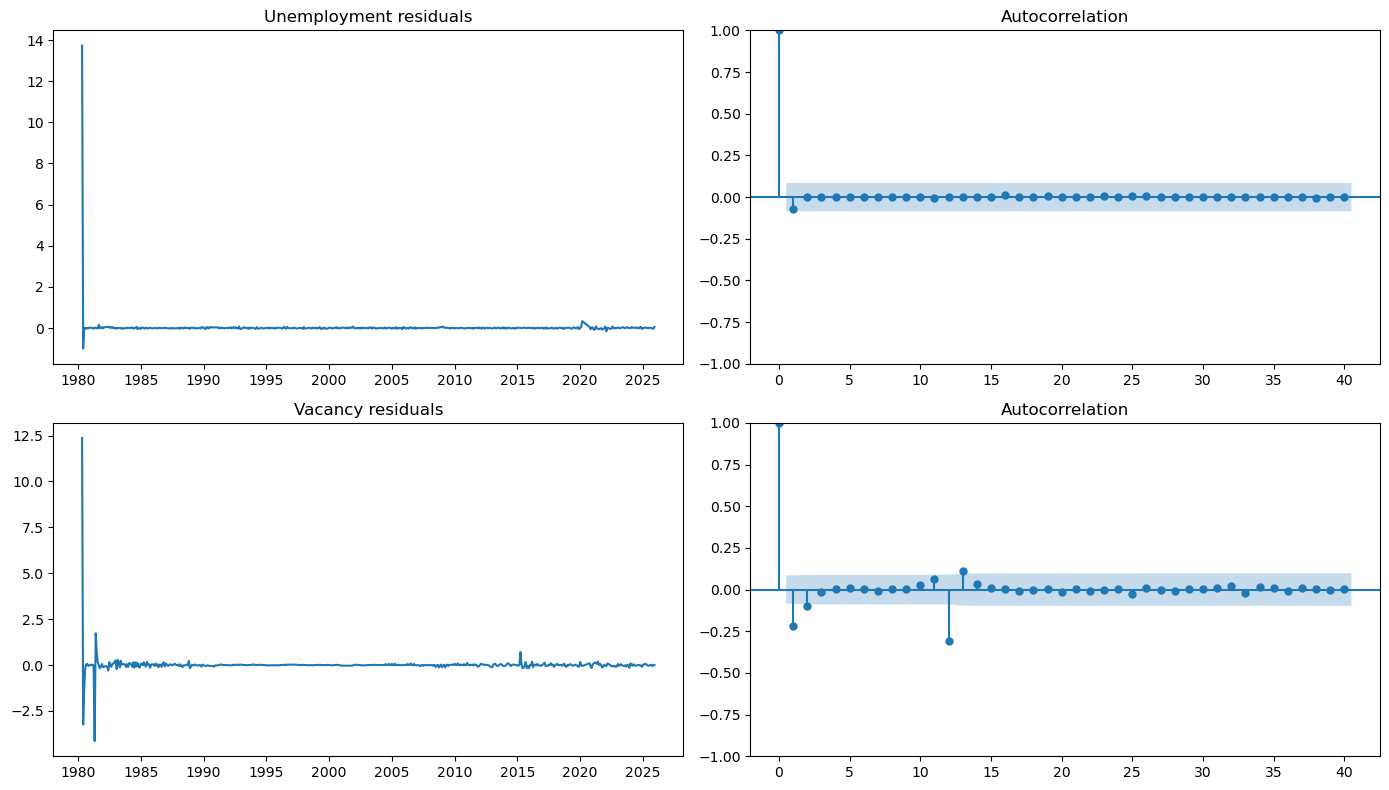

In [98]:
# ---------------------------------------------------
# STEP 3.7 — Residual Plots
# ---------------------------------------------------

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(2,2, figsize=(14,8))

axes[0,0].plot(fit_u.resid)
axes[0,0].set_title("Unemployment residuals")

plot_acf(fit_u.resid, lags=40, ax=axes[0,1])

axes[1,0].plot(fit_v.resid)
axes[1,0].set_title("Vacancy residuals")

plot_acf(fit_v.resid, lags=40, ax=axes[1,1])

plt.tight_layout()
plt.show()

Train shape: (506, 14)
Test shape : (36, 14)
Train period: 1980-05-01 00:00:00 to 2022-12-01 00:00:00
Test period : 2023-01-01 00:00:00 to 2025-12-01 00:00:00

Frozen SARIMAX models fitted successfully.

Forecast comparison preview:


,actual_unemployment,forecast_unemployment,actual_vacancies,forecast_vacancies,actual_theta,forecast_theta,forecast_log_unemployment,forecast_log_vacancies
month,,,,,,,,
2023-01-01,1083700,1.049995e+06,788280.0,747093.599955,0.727397,0.711521,13.864296,13.523947
2023-02-01,1096300,1.049833e+06,747720.0,734877.799313,0.682040,0.699995,13.864143,13.507461
2023-03-01,1079200,1.049810e+06,790370.0,781236.400785,0.732367,0.744170,13.864120,13.568634
2023-04-01,1080700,1.049806e+06,839950.0,788138.775552,0.777228,0.750747,13.864117,13.577431
2023-05-01,1111300,1.049806e+06,812510.0,773884.952621,0.731135,0.737170,13.864117,13.559180



Frozen SARIMAX metrics summary:


,model,target,RMSE,MAE,MAPE,sMAPE,MASE,train_end_date,test_start_date,test_end_date,n_eval
0,SARIMAX,unemployment,363001.307761,319354.968264,22.013840,25.489635,10.932535,2022-12-01,2023-01-01,2025-12-01,36
1,SARIMAX,vacancies,170543.610986,148833.632251,28.105786,23.502640,4.730777,2022-12-01,2023-01-01,2025-12-01,36
2,SARIMAX,theta,0.282895,0.250614,68.864148,46.795976,8.800282,2022-12-01,2023-01-01,2025-12-01,36



Standardized export preview:


,model_name,target,origin_date,train_end_date,forecast_date,forecast_horizon,predicted_value,actual_value
0,SARIMAX,unemployment,2022-12-01,2022-12-01,2023-01-01,1,1.049995e+06,1083700.0
1,SARIMAX,unemployment,2022-12-01,2022-12-01,2023-02-01,2,1.049833e+06,1096300.0
2,SARIMAX,unemployment,2022-12-01,2022-12-01,2023-03-01,3,1.049810e+06,1079200.0
3,SARIMAX,unemployment,2022-12-01,2022-12-01,2023-04-01,4,1.049806e+06,1080700.0
4,SARIMAX,unemployment,2022-12-01,2022-12-01,2023-05-01,5,1.049806e+06,1111300.0
5,SARIMAX,unemployment,2022-12-01,2022-12-01,2023-06-01,6,1.049806e+06,1153200.0
6,SARIMAX,unemployment,2022-12-01,2022-12-01,2023-07-01,7,1.049806e+06,1172200.0
7,SARIMAX,unemployment,2022-12-01,2022-12-01,2023-08-01,8,1.049806e+06,1164700.0
8,SARIMAX,unemployment,2022-12-01,2022-12-01,2023-09-01,9,1.049806e+06,1181400.0
9,SARIMAX,unemployment,2022-12-01,2022-12-01,2023-10-01,10,1.049806e+06,1235900.0


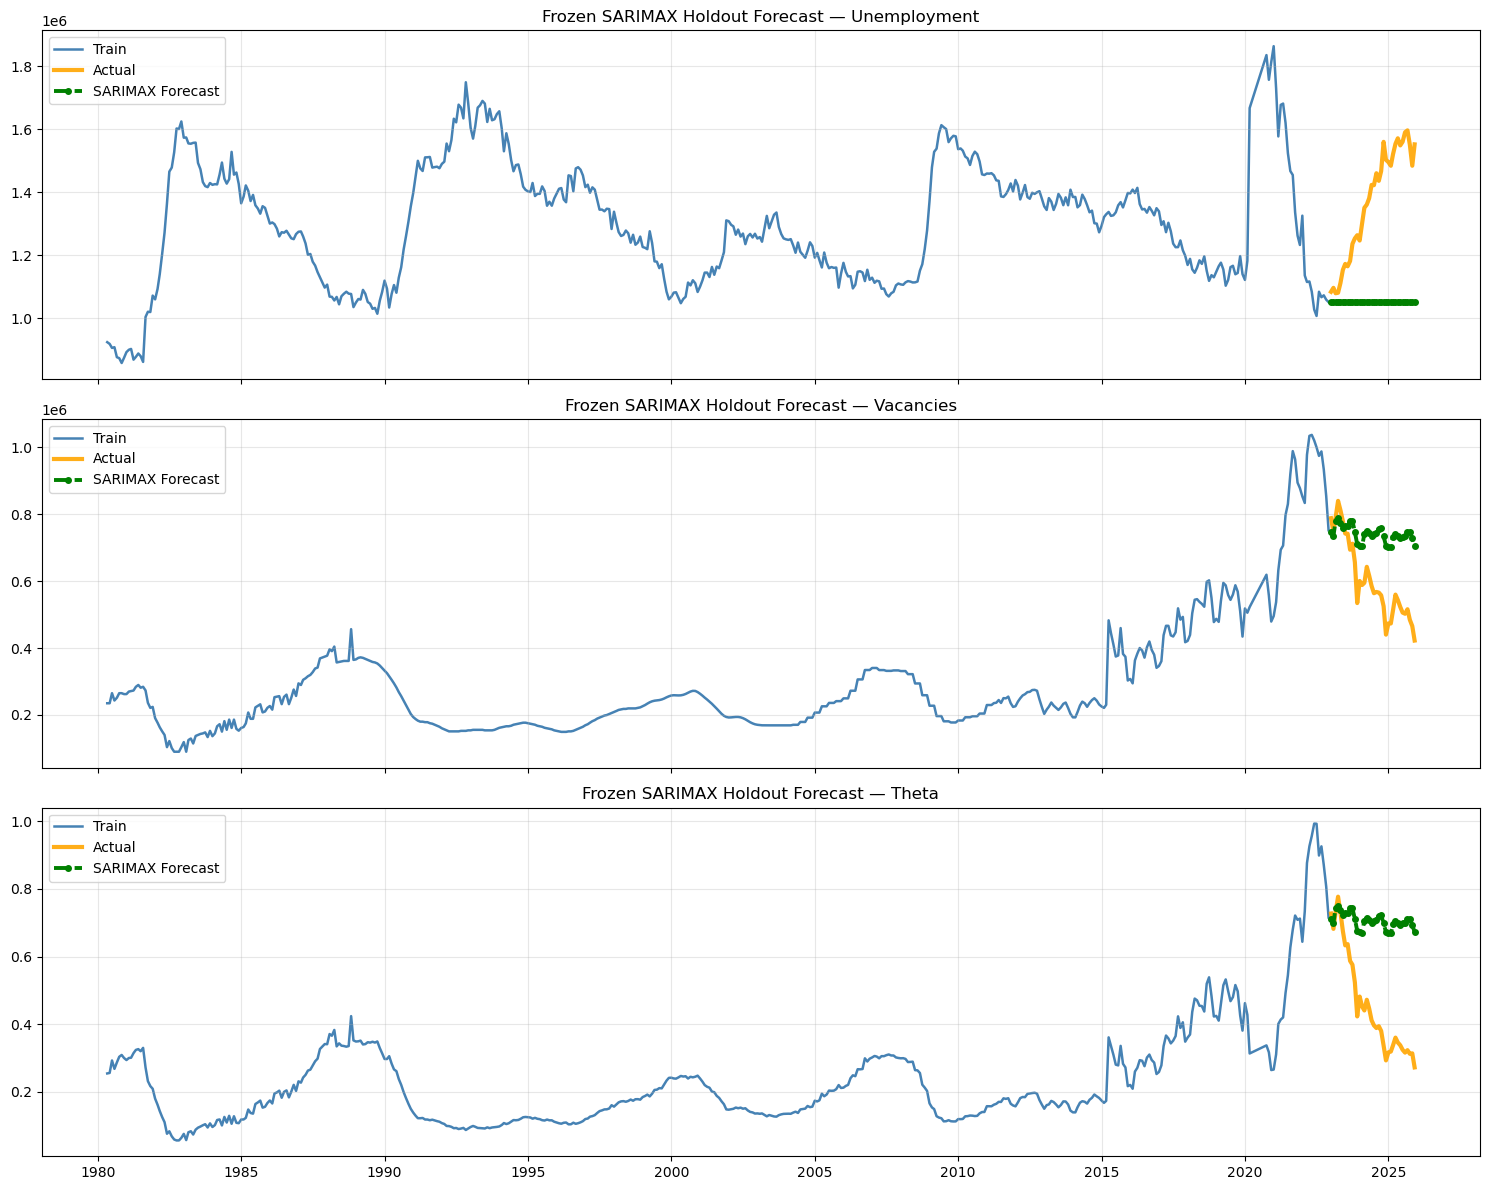


SARIMAX freeze stage completed successfully.
Objects created:
 - results
 - metrics_df
 - forecast_export


In [119]:
# ============================================================
# STEP S10–S11 — FROZEN SARIMAX HOLDOUT FORECAST, METRICS,
# EXPORT, AND CLEAR VISUALS
# ============================================================
# Purpose:
#   1. Refit frozen SARIMAX benchmark models on training data
#   2. Generate holdout forecasts for unemployment and vacancies
#   3. Derive theta = vacancies / unemployment
#   4. Compute RMSE, MAE, MAPE, sMAPE, MASE safely
#   5. Build standardized long-format export contract
#   6. Produce clear visuals where forecast is visible
#
# Locked benchmark specifications from earlier notebook stages:
#   - Unemployment: SARIMA(1,1,0)
#   - Vacancies:    SARIMA(2,1,1)(1,0,1)[12]
#
# IMPORTANT:
#   This cell is designed to replace the old Phase 4 / error cells.
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ------------------------------------------------------------
# 0. Safe display fallback
# ------------------------------------------------------------
try:
    display
except NameError:
    def display(x):
        print(x)

# ------------------------------------------------------------
# 1. Frozen configuration
# ------------------------------------------------------------
MODEL_NAME = "SARIMAX"
TRAIN_END = "2022-12-01"
TEST_START = "2023-01-01"

# Locked orders from your earlier SARIMA selection
U_ORDER = (1, 1, 0)
U_SEASONAL = (0, 0, 0, 12)

V_ORDER = (2, 1, 1)
V_SEASONAL = (1, 0, 1, 12)

# ------------------------------------------------------------
# 2. Load data safely
# ------------------------------------------------------------
sarima_df = None

# Use df from notebook if already available
if "df" in globals():
    sarima_df = df.copy()

# Otherwise import canonical loader
if sarima_df is None:
    try:
        from data_loader import load_dataset
        sarima_df = load_dataset(verbose=False).copy()
    except Exception:
        possible_paths = [
            Path.cwd(),
            Path.cwd().parent,
            Path.cwd() / "utils",
            Path.cwd().parent / "utils",
            Path.cwd() / "4_predictive_forecasting" / "utils",
            Path.cwd().parent / "4_predictive_forecasting" / "utils",
        ]

        loaded = False
        for p in possible_paths:
            if p.exists() and str(p) not in sys.path:
                sys.path.append(str(p))
            try:
                from data_loader import load_dataset
                sarima_df = load_dataset(verbose=False).copy()
                loaded = True
                break
            except Exception:
                continue

        if not loaded:
            raise ImportError(
                "Could not load dataset. Make sure data_loader.py is available or df already exists."
            )

# ------------------------------------------------------------
# 3. Validate and prepare data
# ------------------------------------------------------------
sarima_df = sarima_df.copy()

# Ensure datetime index
if "month" in sarima_df.columns:
    sarima_df["month"] = pd.to_datetime(sarima_df["month"])
    sarima_df = sarima_df.set_index("month")

sarima_df.index = pd.to_datetime(sarima_df.index)
sarima_df = sarima_df.sort_index()

required_cols = ["unemployment", "vacancies", "theta"]
missing_cols = [c for c in required_cols if c not in sarima_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

for c in required_cols:
    sarima_df[c] = pd.to_numeric(sarima_df[c], errors="coerce")

if sarima_df[required_cols].isna().any().any():
    raise ValueError(
        "NaN values found in unemployment/vacancies/theta. "
        "Please clean the dataset before running the frozen SARIMAX cell."
    )

# Safe log transform
sarima_df["log_unemployment"] = np.log1p(sarima_df["unemployment"])
sarima_df["log_vacancies"] = np.log1p(sarima_df["vacancies"])

# ------------------------------------------------------------
# 4. Train / test split
# ------------------------------------------------------------
train = sarima_df.loc[:TRAIN_END].copy()
test = sarima_df.loc[TEST_START:].copy()

if train.empty:
    raise ValueError("Training set is empty. Check TRAIN_END.")
if test.empty:
    raise ValueError("Test set is empty. Check TEST_START.")

print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("Train period:", train.index.min(), "to", train.index.max())
print("Test period :", test.index.min(), "to", test.index.max())

# ------------------------------------------------------------
# 5. Fit frozen SARIMAX model — unemployment
# ------------------------------------------------------------
u_model = SARIMAX(
    endog=train["log_unemployment"],
    order=U_ORDER,
    seasonal_order=U_SEASONAL,
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False
)
u_fit = u_model.fit(disp=False)

# ------------------------------------------------------------
# 6. Fit frozen SARIMAX model — vacancies
# ------------------------------------------------------------
v_model = SARIMAX(
    endog=train["log_vacancies"],
    order=V_ORDER,
    seasonal_order=V_SEASONAL,
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False
)
v_fit = v_model.fit(disp=False)

print("\nFrozen SARIMAX models fitted successfully.")

# ------------------------------------------------------------
# 7. Generate holdout forecasts
# ------------------------------------------------------------
h = len(test)

u_fc_obj = u_fit.get_forecast(steps=h)
v_fc_obj = v_fit.get_forecast(steps=h)

u_fc_log = pd.Series(np.asarray(u_fc_obj.predicted_mean), index=test.index, name="forecast_log_unemployment")
v_fc_log = pd.Series(np.asarray(v_fc_obj.predicted_mean), index=test.index, name="forecast_log_vacancies")

# Convert back to levels
u_fc_level = pd.Series(np.expm1(u_fc_log), index=test.index, name="forecast_unemployment").clip(lower=0)
v_fc_level = pd.Series(np.expm1(v_fc_log), index=test.index, name="forecast_vacancies").clip(lower=0)

# Derived theta forecast
theta_fc = pd.Series(
    np.where(u_fc_level > 0, v_fc_level / u_fc_level, np.nan),
    index=test.index,
    name="forecast_theta"
)

# ------------------------------------------------------------
# 8. Build comparison table
# ------------------------------------------------------------
results = pd.DataFrame(index=test.index)
results["actual_unemployment"] = test["unemployment"].values
results["forecast_unemployment"] = u_fc_level.values

results["actual_vacancies"] = test["vacancies"].values
results["forecast_vacancies"] = v_fc_level.values

results["actual_theta"] = test["theta"].values
results["forecast_theta"] = theta_fc.values

results["forecast_log_unemployment"] = u_fc_log.values
results["forecast_log_vacancies"] = v_fc_log.values

print("\nForecast comparison preview:")
display(results.head())

# ------------------------------------------------------------
# 9. Safe metrics
# ------------------------------------------------------------
def clean_metric_inputs(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = (
        ~np.isnan(y_true) &
        ~np.isnan(y_pred) &
        ~np.isinf(y_true) &
        ~np.isinf(y_pred)
    )
    return y_true[mask], y_pred[mask]

def safe_mape(y_true, y_pred):
    y_true, y_pred = clean_metric_inputs(y_true, y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def safe_smape(y_true, y_pred):
    y_true, y_pred = clean_metric_inputs(y_true, y_pred)
    denom = np.abs(y_true) + np.abs(y_pred)
    mask = denom != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(2 * np.abs(y_pred[mask] - y_true[mask]) / denom[mask]) * 100

def safe_mase(y_true, y_pred):
    y_true, y_pred = clean_metric_inputs(y_true, y_pred)
    if len(y_true) < 2:
        return np.nan
    naive_denom = np.mean(np.abs(np.diff(y_true)))
    if naive_denom == 0:
        return np.nan
    mae_val = np.mean(np.abs(y_true - y_pred))
    return mae_val / naive_denom

target_map = {
    "unemployment": ("actual_unemployment", "forecast_unemployment"),
    "vacancies": ("actual_vacancies", "forecast_vacancies"),
    "theta": ("actual_theta", "forecast_theta"),
}

metric_rows = []

for target_name, (actual_col, forecast_col) in target_map.items():
    y_true_raw = results[actual_col].values
    y_pred_raw = results[forecast_col].values

    y_true, y_pred = clean_metric_inputs(y_true_raw, y_pred_raw)

    if len(y_true) == 0:
        row = {
            "model": MODEL_NAME,
            "target": target_name,
            "RMSE": np.nan,
            "MAE": np.nan,
            "MAPE": np.nan,
            "sMAPE": np.nan,
            "MASE": np.nan,
            "train_end_date": pd.to_datetime(TRAIN_END),
            "test_start_date": pd.to_datetime(TEST_START),
            "test_end_date": results.index.max(),
            "n_eval": 0
        }
    else:
        row = {
            "model": MODEL_NAME,
            "target": target_name,
            "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
            "MAE": mean_absolute_error(y_true, y_pred),
            "MAPE": safe_mape(y_true, y_pred),
            "sMAPE": safe_smape(y_true, y_pred),
            "MASE": safe_mase(y_true, y_pred),
            "train_end_date": pd.to_datetime(TRAIN_END),
            "test_start_date": pd.to_datetime(TEST_START),
            "test_end_date": results.index.max(),
            "n_eval": len(y_true)
        }

    metric_rows.append(row)

metrics_df = pd.DataFrame(metric_rows)

print("\nFrozen SARIMAX metrics summary:")
display(metrics_df)

# ------------------------------------------------------------
# 10. Standardized long-format export contract
# ------------------------------------------------------------
export_frames = []

for target_name, (actual_col, forecast_col) in target_map.items():
    temp = pd.DataFrame({
        "model_name": MODEL_NAME,
        "target": target_name,
        "origin_date": pd.to_datetime(TRAIN_END),
        "train_end_date": pd.to_datetime(TRAIN_END),
        "forecast_date": results.index,
        "forecast_horizon": np.arange(1, len(results) + 1),
        "predicted_value": results[forecast_col].values,
        "actual_value": results[actual_col].values
    })
    export_frames.append(temp)

forecast_export = pd.concat(export_frames, ignore_index=True)

print("\nStandardized export preview:")
display(forecast_export.head(10))

# ------------------------------------------------------------
# 11. Clear visuals
#     Forecast line is drawn last, thicker, dashed, and with markers
# ------------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

plot_specs = [
    ("unemployment", "actual_unemployment", "forecast_unemployment", "Frozen SARIMAX Holdout Forecast — Unemployment"),
    ("vacancies", "actual_vacancies", "forecast_vacancies", "Frozen SARIMAX Holdout Forecast — Vacancies"),
    ("theta", "actual_theta", "forecast_theta", "Frozen SARIMAX Holdout Forecast — Theta"),
]

for ax, (label_name, actual_col, forecast_col, title_text) in zip(axes, plot_specs):
    # train
    ax.plot(
        train.index,
        train[label_name],
        label="Train",
        color="steelblue",
        linewidth=1.8,
        zorder=1
    )

    # actual holdout
    ax.plot(
        test.index,
        test[label_name],
        label="Actual",
        color="orange",
        linewidth=3.0,
        alpha=0.9,
        zorder=2
    )

    # forecast holdout
    ax.plot(
        results.index,
        results[forecast_col],
        label="SARIMAX Forecast",
        color="green",
        linestyle="--",
        linewidth=2.8,
        marker="o",
        markersize=4,
        zorder=3
    )

    ax.set_title(title_text)
    ax.legend(loc="upper left")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 12. Optional CSV export
#     Uncomment if needed
# ------------------------------------------------------------
# export_dir = Path("../exports/base_models")
# export_dir.mkdir(parents=True, exist_ok=True)
# results.to_csv(export_dir / "sarimax_holdout_results_wide.csv")
# metrics_df.to_csv(export_dir / "sarimax_holdout_metrics.csv", index=False)
# forecast_export.to_csv(export_dir / "sarimax_holdout_forecasts_long.csv", index=False)

print("\nSARIMAX freeze stage completed successfully.")
print("Objects created:")
print(" - results")
print(" - metrics_df")
print(" - forecast_export")

In [120]:
# =============================================================================
# EXPORT SARIMAX TEST PREDICTIONS (FINAL COMPARISON)
# =============================================================================

from pathlib import Path
import pandas as pd

EXPORT_DIR = Path("exports/test_predictions")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

def export_target(df, target):

    temp = df[df["target"] == target].copy()

    out = pd.DataFrame({
        "month": temp["forecast_date"],
        "actual": temp["actual_value"],
        "prediction": temp["predicted_value"]
    })

    out = out.sort_values("month").reset_index(drop=True)

    out_path = EXPORT_DIR / f"sarimax_{target}.csv"
    out.to_csv(out_path, index=False)

    print(f"Saved: {out_path} | shape={out.shape}")

export_target(forecast_export, "unemployment")
export_target(forecast_export, "vacancies")
export_target(forecast_export, "theta")

Saved: exports\test_predictions\sarimax_unemployment.csv | shape=(36, 3)
Saved: exports\test_predictions\sarimax_vacancies.csv | shape=(36, 3)
Saved: exports\test_predictions\sarimax_theta.csv | shape=(36, 3)
